In [2]:
import yaml

import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [3]:

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

project_root = Path('.').resolve()
if not (project_root / 'data').exists() and (project_root.parent / 'data').exists():
    project_root = project_root.parent

data_root = project_root / 'data'
roboflow_root = data_root / 'raw' / 'roboflow_menu_text_box_v3' / 'Menu Text Box'
kaggle_root = data_root / 'raw' / 'kaggle_indian_menu_cards'

data_yaml = roboflow_root / "data.yaml"
data_cfg = yaml.safe_load(data_yaml.read_text(encoding="utf-8", errors="ignore"))
names = data_cfg.get("names")
class_names = [names[k] for k in sorted(names)] if isinstance(names, dict) else list(names)
nc = data_cfg.get("nc", len(class_names))

print("project_root", project_root)
print("roboflow_root_exists", roboflow_root.exists())
print("kaggle_root_exists", kaggle_root.exists())
print("roboflow_data_yaml", data_yaml)
print("roboflow_nc", nc)
print("roboflow_class_names", class_names)

splits = ["train", "valid", "test"]
rows = []
for split in splits:
    img_dir = roboflow_root / split / "images"
    lbl_dir = roboflow_root / split / "labels"

    imgs = sorted([p for p in img_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
    lbls = sorted([p for p in lbl_dir.rglob("*.txt") if p.is_file()])

    empty_lbl = 0
    poly_lines = 0
    bad_lines = 0

    for lp in lbls:
        txt = lp.read_text(encoding="utf-8", errors="ignore").strip()
        if txt == "":
            empty_lbl += 1
            continue
        for line in txt.splitlines():
            parts = line.strip().split()
            if len(parts) == 5:
                continue
            if len(parts) > 5 and (len(parts) - 1) % 2 == 0:
                poly_lines += 1
                continue
            bad_lines += 1

    rows.append([split, len(imgs), len(lbls), empty_lbl, poly_lines, bad_lines])

rf_stats = pd.DataFrame(rows, columns=["split", "n_images", "n_labels", "empty_label_files", "poly_lines", "bad_lines"])
rf_stats

kaggle_images = sorted([p for p in kaggle_root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
kaggle_txt = sorted([p for p in kaggle_root.rglob("*.txt") if p.is_file()])

print("kaggle_images", len(kaggle_images))
print("kaggle_txt_files", len(kaggle_txt))


project_root /Users/renataalieva/Desktop/MDS/pickmeal-ml
roboflow_root_exists True
kaggle_root_exists True
roboflow_data_yaml /Users/renataalieva/Desktop/MDS/pickmeal-ml/data/raw/roboflow_menu_text_box_v3/Menu Text Box/data.yaml
roboflow_nc 2
roboflow_class_names ['menu-text', 'res_name']
kaggle_images 7790
kaggle_txt_files 0


In [4]:
rows = []
lbl_rows = []
bad_lines = 0

for split in splits:
    img_dir = roboflow_root / split / "images"
    lbl_dir = roboflow_root / split / "labels"

    imgs = sorted([p for p in img_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
    lbl_map = {p.stem: p for p in lbl_dir.rglob("*.txt") if p.is_file()}

    for img in imgs:
        lp = lbl_map[img.stem]

        with Image.open(img) as im:
            w, h = im.size

        rows.append([
            split,
            str(img.relative_to(project_root)),
            str(lp.relative_to(project_root)),
            w,
            h,
            img.stat().st_size,
            lp.stat().st_size,
        ])

        txt = lp.read_text(encoding="utf-8", errors="ignore").strip()
        if txt == "":
            continue

        for line in txt.splitlines():
            parts = line.strip().split()

            if len(parts) == 5:
                try:
                    cls = int(float(parts[0]))
                    xc, yc, bw, bh = map(float, parts[1:])
                    src = "yolo"
                except Exception:
                    bad_lines += 1
                    continue

            elif len(parts) > 5 and (len(parts) - 1) % 2 == 0:
                try:
                    cls = int(float(parts[0]))
                    coords = list(map(float, parts[1:]))
                    xs = coords[0::2]
                    ys = coords[1::2]
                    xmin, xmax = min(xs), max(xs)
                    ymin, ymax = min(ys), max(ys)
                    xc = (xmin + xmax) / 2
                    yc = (ymin + ymax) / 2
                    bw = xmax - xmin
                    bh = ymax - ymin
                    src = "poly"
                except Exception:
                    bad_lines += 1
                    continue

            else:
                bad_lines += 1
                continue

            lbl_rows.append([split, str(img.relative_to(project_root)), cls, xc, yc, bw, bh, src])

images_rf = pd.DataFrame(rows, columns=["split", "image_path", "label_path", "img_w", "img_h", "image_bytes", "label_bytes"])
boxes_rf = pd.DataFrame(lbl_rows, columns=["split", "image_path", "class_id", "xc", "yc", "bw", "bh", "src"])

boxes_rf["class_name"] = [class_names[i] if 0 <= i < len(class_names) else str(i) for i in boxes_rf["class_id"]]

box_counts = boxes_rf.groupby(["split", "image_path"]).size().rename("n_boxes").reset_index()
images_rf = images_rf.merge(box_counts, on=["split", "image_path"], how="left")
images_rf["n_boxes"] = images_rf["n_boxes"].fillna(0).astype(int)
images_rf["label_empty"] = images_rf["label_bytes"].eq(0)

print("images_total", len(images_rf))
print("boxes_total", len(boxes_rf))
print("bad_lines", bad_lines)
print("poly_converted", int((boxes_rf["src"] == "poly").sum()))
print("unique_class_ids", sorted(boxes_rf["class_id"].unique()))

display(images_rf.groupby("split").agg(
    n_images=("image_path", "count"),
    empty_label_files=("label_empty", "sum"),
    mean_boxes=("n_boxes", "mean"),
    median_boxes=("n_boxes", "median"),
    p95_boxes=("n_boxes", lambda s: float(np.percentile(s, 95))),
))

boxes_rf.groupby(["split", "class_name"]).size().unstack(fill_value=0)


images_total 4757
boxes_total 20217
bad_lines 0
poly_converted 1
unique_class_ids [np.int64(0), np.int64(1)]


,n_images,empty_label_files,mean_boxes,median_boxes,p95_boxes
split,,,,,
test,290,15,4.048276,3.0,10.0
train,4005,18,4.270412,3.0,10.0
valid,462,1,4.199134,3.0,10.0


class_name,menu-text,res_name
split,,
test,1155,19
train,16377,726
valid,1877,63


In [5]:
removed_rf = images_rf[images_rf["label_empty"]].copy()
images_rf_labeled = images_rf[~images_rf["label_empty"]].copy()
boxes_rf_labeled = boxes_rf.merge(
    images_rf_labeled[["split", "image_path", "img_w", "img_h"]],
    on=["split", "image_path"],
    how="inner",
)

summary = images_rf.groupby("split").agg(
    n_images=("image_path", "count"),
    n_empty=("label_empty", "sum"),
)
summary["pct_empty"] = (100 * summary["n_empty"] / summary["n_images"]).round(2)

print("images_total", len(images_rf), "-> labeled_images", len(images_rf_labeled))
print("boxes_total", len(boxes_rf), "-> labeled_boxes", len(boxes_rf_labeled))
display(summary)

display(
    boxes_rf_labeled.groupby(["split", "class_name"]).size().unstack(fill_value=0)
)

removed_rf[["split", "image_path", "img_w", "img_h", "image_bytes"]].head(10)


images_total 4757 -> labeled_images 4723
boxes_total 20217 -> labeled_boxes 20217


,n_images,n_empty,pct_empty
split,,,
test,290,15,5.17
train,4005,18,0.45
valid,462,1,0.22


class_name,menu-text,res_name
split,,
test,1155,19
train,16377,726
valid,1877,63


,split,image_path,img_w,img_h,image_bytes
60,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,75,75,1425
61,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,75,75,1112
62,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,75,75,1395
936,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,55918
937,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,58916
938,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,73237
1416,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,58589
1417,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,57241
1418,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,63679
2058,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,10765


removed_total 34


split
test     15
train    18
valid     1
dtype: int64

split  img_w  img_h
train  1024   682      3
       564    846      3
              364      3
       563    784      3
       235    180      3
       75     75       3
test   75     75       1
       369    638      1
       1448   2048     1
       1024   742      1
       650    465      1
              451      1
       512    700      1
       419    700      1
       416    700      1
       405    691      1
       390    677      1
       389    550      1
       383    691      1
       382    674      1
       376    642      1
valid  564    797      1
dtype: int64

tiny_removed 4


split
test     1
train    3
dtype: int64

normal_removed 30


split
test     14
train    15
valid     1
dtype: int64

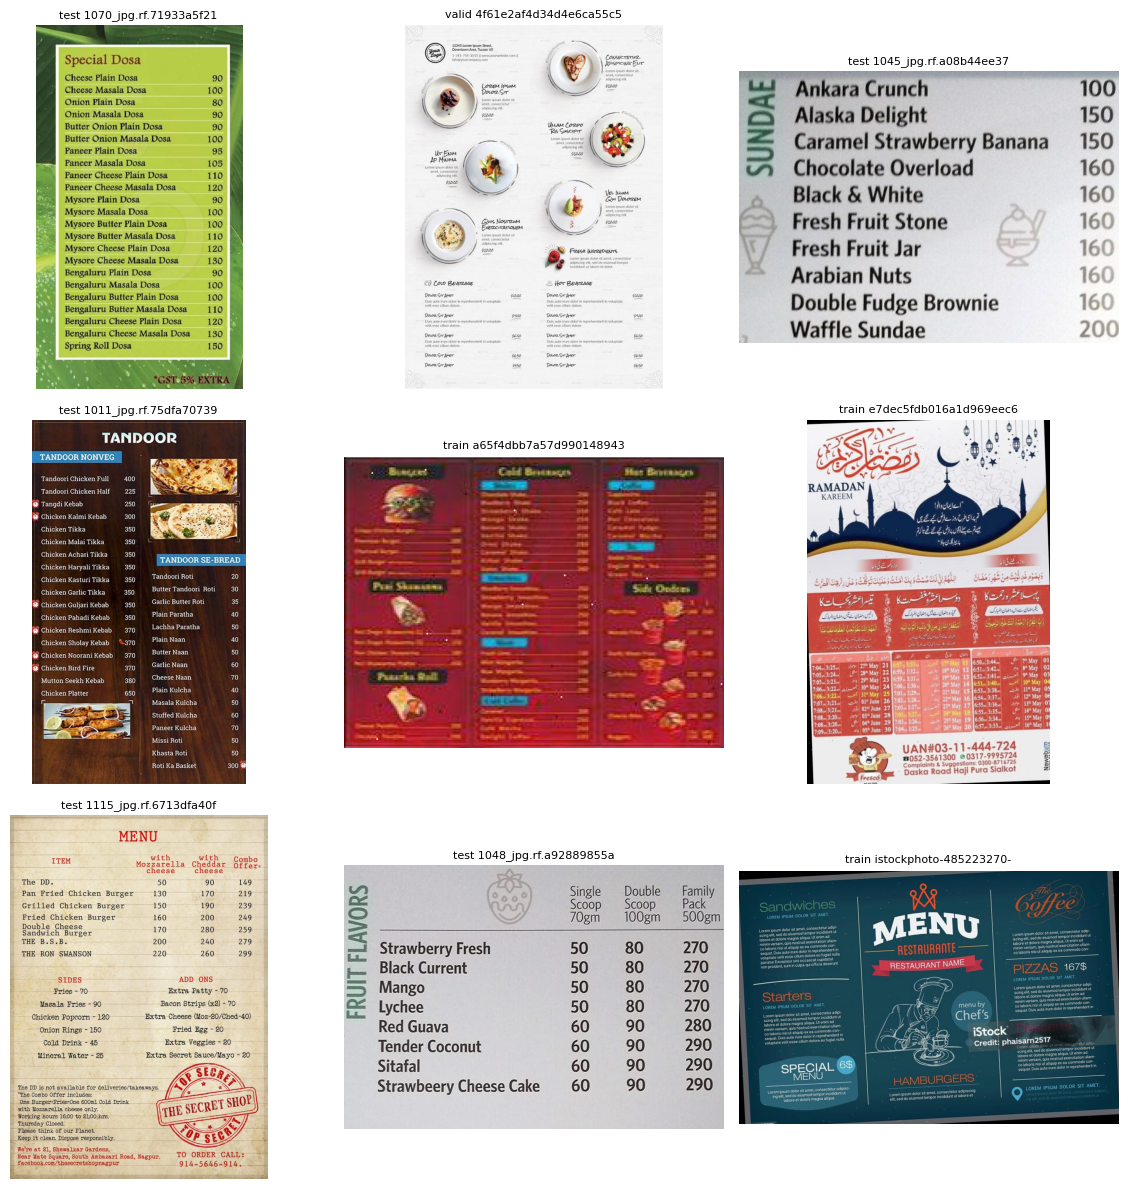

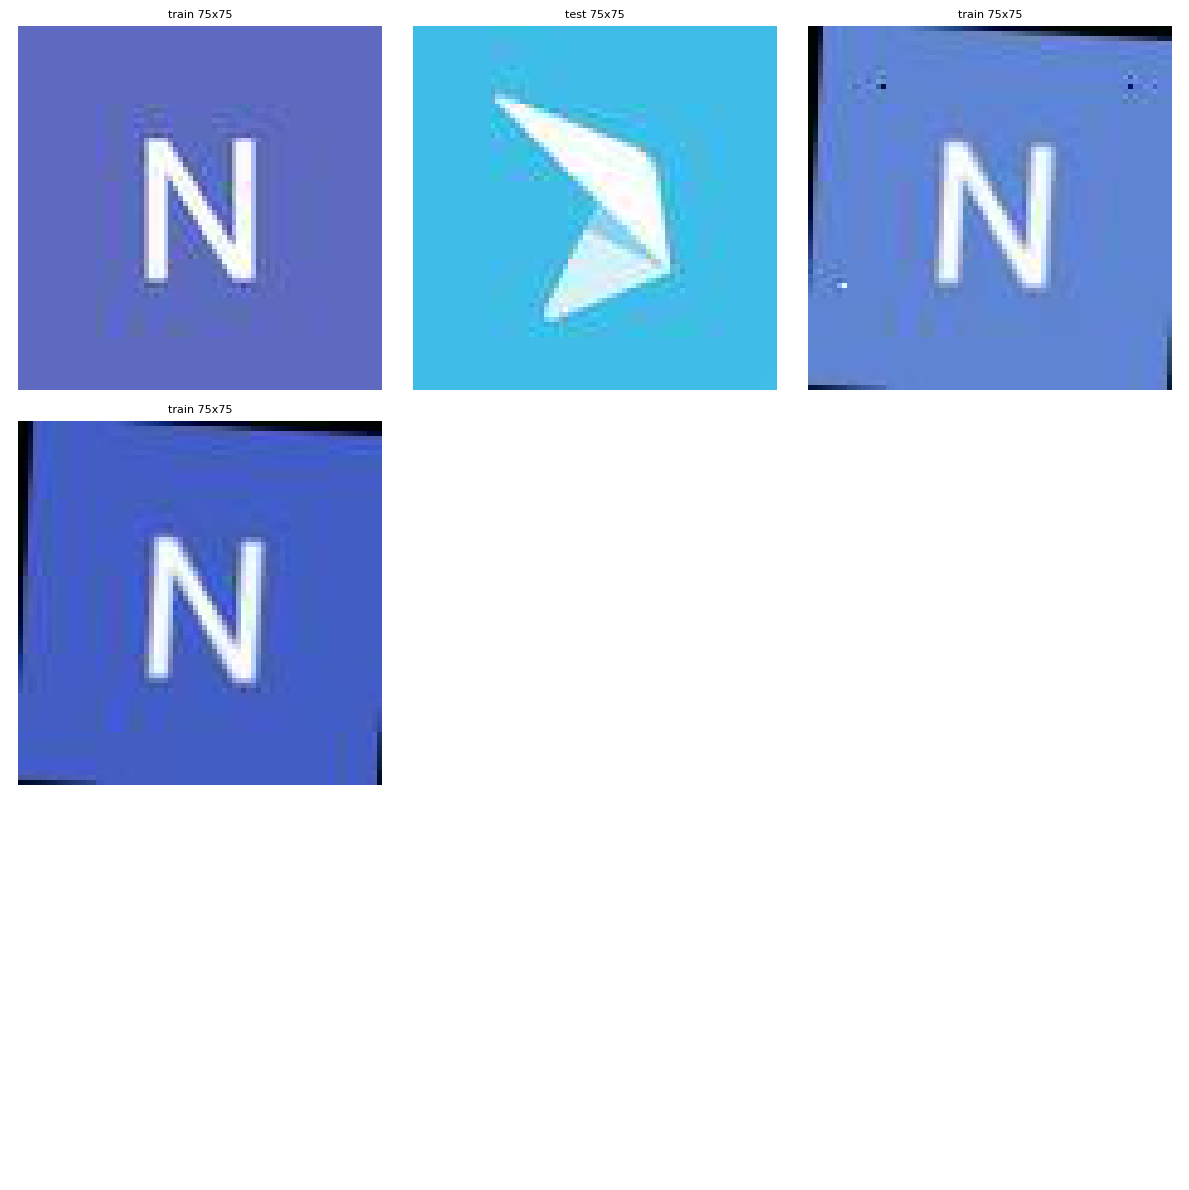

In [6]:
print("removed_total", len(removed_rf))
display(removed_rf.groupby("split").size())

display(
    removed_rf.groupby(["split", "img_w", "img_h"])
    .size()
    .sort_values(ascending=False)
    .head(30)
)

tiny = removed_rf[(removed_rf["img_w"] <= 100) | (removed_rf["img_h"] <= 100)].copy()
normal = removed_rf[(removed_rf["img_w"] > 100) & (removed_rf["img_h"] > 100)].copy()

print("tiny_removed", len(tiny))
display(tiny.groupby("split").size())

print("normal_removed", len(normal))
display(normal.groupby("split").size())

sample_normal = normal.sample(n=min(9, len(normal)), random_state=42)
sample_tiny = tiny.sample(n=min(9, len(tiny)), random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")

for ax, (_, r) in zip(axes, sample_normal.iterrows()):
    img = Image.open(project_root / r["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{r['split']} {Path(r['image_path']).name[:22]}", fontsize=8)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")

for ax, (_, r) in zip(axes, sample_tiny.iterrows()):
    img = Image.open(project_root / r["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{r['split']} {r['img_w']}x{r['img_h']}", fontsize=8)

plt.tight_layout()
plt.show()


In [7]:
images_rf["min_side"] = images_rf[["img_w", "img_h"]].min(axis=1)
images_rf["is_tiny"] = images_rf["min_side"] < 150

rf_supervised = images_rf[~images_rf["label_empty"] & ~images_rf["is_tiny"]].copy()
rf_unlabeled_missing = images_rf[images_rf["label_empty"] & ~images_rf["is_tiny"]].copy()
rf_noise = images_rf[images_rf["label_empty"] & images_rf["is_tiny"]].copy()
rf_labeled_tiny = images_rf[~images_rf["label_empty"] & images_rf["is_tiny"]].copy()

print("rf_supervised_images", len(rf_supervised))
print("rf_unlabeled_missing_images", len(rf_unlabeled_missing))
print("rf_noise_images", len(rf_noise))
print("rf_labeled_tiny_images", len(rf_labeled_tiny))

display(rf_supervised.groupby("split").size())
display(rf_unlabeled_missing.groupby("split").size())
display(rf_noise.groupby("split").size())

boxes_rf_supervised = boxes_rf.merge(rf_supervised[["split", "image_path"]], on=["split", "image_path"], how="inner")

display(
    boxes_rf_supervised.groupby(["split", "class_name"]).size().unstack(fill_value=0)
)

rf_unlabeled_missing[["split", "image_path", "img_w", "img_h", "image_bytes"]].head(10)


rf_supervised_images 4720
rf_unlabeled_missing_images 30
rf_noise_images 4
rf_labeled_tiny_images 3


split
test      275
train    3984
valid     461
dtype: int64

split
test     14
train    15
valid     1
dtype: int64

split
test     1
train    3
dtype: int64

class_name,menu-text,res_name
split,,
test,1155,19
train,16374,726
valid,1877,63


,split,image_path,img_w,img_h,image_bytes
936,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,55918
937,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,58916
938,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,364,73237
1416,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,58589
1417,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,57241
1418,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,563,784,63679
2058,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,10765
2059,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,12860
2060,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,235,180,10970
2775,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,564,846,97621


In [8]:
rf_supervised["aspect_ratio"] = rf_supervised["img_w"] / rf_supervised["img_h"]
rf_supervised["img_area"] = rf_supervised["img_w"] * rf_supervised["img_h"]

boxes_sup = boxes_rf_supervised.merge(
    rf_supervised[["split", "image_path", "img_w", "img_h"]],
    on=["split", "image_path"],
    how="left",
)

boxes_sup["bbox_area_frac"] = boxes_sup["bw"] * boxes_sup["bh"]
boxes_sup["bbox_w_px"] = boxes_sup["bw"] * boxes_sup["img_w"]
boxes_sup["bbox_h_px"] = boxes_sup["bh"] * boxes_sup["img_h"]

boxes_sup["x1"] = (boxes_sup["xc"] - boxes_sup["bw"] / 2) * boxes_sup["img_w"]
boxes_sup["y1"] = (boxes_sup["yc"] - boxes_sup["bh"] / 2) * boxes_sup["img_h"]
boxes_sup["x2"] = (boxes_sup["xc"] + boxes_sup["bw"] / 2) * boxes_sup["img_w"]
boxes_sup["y2"] = (boxes_sup["yc"] + boxes_sup["bh"] / 2) * boxes_sup["img_h"]

boxes_sup["oob"] = (
    (boxes_sup["x1"] < -1) |
    (boxes_sup["y1"] < -1) |
    (boxes_sup["x2"] > boxes_sup["img_w"] + 1) |
    (boxes_sup["y2"] > boxes_sup["img_h"] + 1) |
    (boxes_sup["x2"] <= boxes_sup["x1"]) |
    (boxes_sup["y2"] <= boxes_sup["y1"])
)

print("images_supervised", len(rf_supervised))
print("boxes_supervised", len(boxes_sup))
print("oob_boxes", int(boxes_sup["oob"].sum()))

display(
    rf_supervised.groupby("split").agg(
        n_images=("image_path", "count"),
        mean_w=("img_w", "mean"),
        mean_h=("img_h", "mean"),
        mean_aspect=("aspect_ratio", "mean"),
        p05_aspect=("aspect_ratio", lambda s: float(np.percentile(s, 5))),
        p95_aspect=("aspect_ratio", lambda s: float(np.percentile(s, 95))),
        mean_area=("img_area", "mean"),
    )
)

display(
    boxes_sup.groupby(["split", "class_name"]).size().unstack(fill_value=0)
)

display(
    boxes_sup.groupby("class_name").agg(
        n=("class_name", "count"),
        mean_area_frac=("bbox_area_frac", "mean"),
        median_area_frac=("bbox_area_frac", "median"),
        p95_area_frac=("bbox_area_frac", lambda s: float(np.percentile(s, 95))),
        mean_w_px=("bbox_w_px", "mean"),
        mean_h_px=("bbox_h_px", "mean"),
    )
)


images_supervised 4720
boxes_supervised 20214
oob_boxes 0


,n_images,mean_w,mean_h,mean_aspect,p05_aspect,p95_aspect,mean_area
split,,,,,,,
test,275,622.363636,736.116364,0.878005,0.573785,1.442348,544245.010909
train,3984,646.444277,797.946536,0.843931,0.548611,1.451765,614668.022590
valid,461,647.969631,791.583514,0.854124,0.554985,1.418136,609050.661605


class_name,menu-text,res_name
split,,
test,1155,19
train,16374,726
valid,1877,63


,n,mean_area_frac,median_area_frac,p95_area_frac,mean_w_px,mean_h_px
class_name,,,,,,
menu-text,19406,0.140930,0.087163,0.469118,297.202419,215.975545
res_name,808,0.035575,0.027206,0.084616,212.967463,72.704901


menu-text


,bbox_area_frac,bbox_w_px,bbox_h_px
0.01,0.006961,58.674,24.4400
0.05,0.015650,85.710,43.3300
0.25,0.044704,160.850,99.0000
0.50,0.087163,241.000,165.5600
0.75,0.168336,394.000,267.4325
0.95,0.469118,646.000,582.0000
0.99,0.888762,1005.950,940.9000


res_name


,bbox_area_frac,bbox_w_px,bbox_h_px
0.01,0.003122,41.0574,18.07
0.05,0.006219,62.3430,23.74
0.25,0.014831,115.9125,37.00
0.50,0.027206,161.3600,57.07
0.75,0.049223,259.0000,95.00
0.95,0.084616,506.5500,170.30
0.99,0.162333,845.0469,262.37


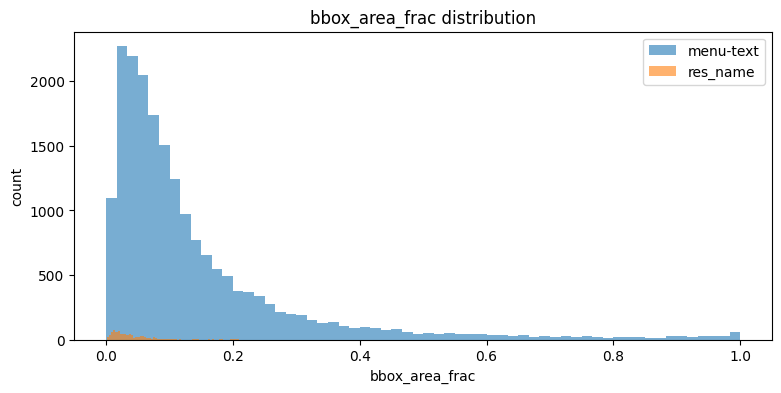

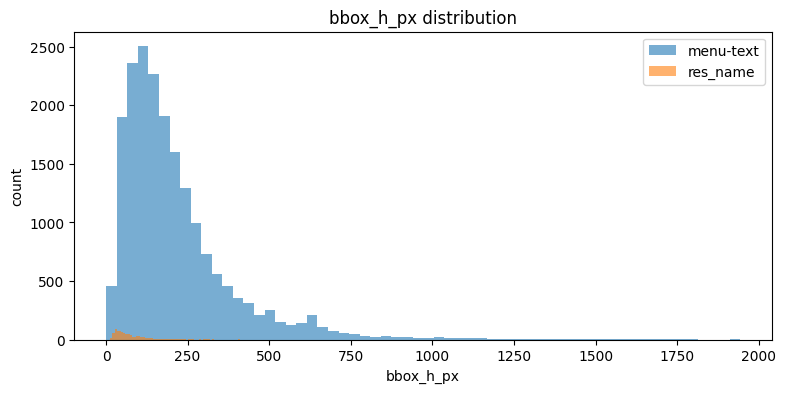

In [9]:
qs = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

for cls in sorted(boxes_sup["class_name"].unique()):
    print(cls)
    display(
        boxes_sup.loc[boxes_sup["class_name"] == cls, ["bbox_area_frac", "bbox_w_px", "bbox_h_px"]]
        .quantile(qs)
    )

fig, ax = plt.subplots(figsize=(9, 4))
for cls in sorted(boxes_sup["class_name"].unique()):
    ax.hist(
        boxes_sup.loc[boxes_sup["class_name"] == cls, "bbox_area_frac"],
        bins=60,
        alpha=0.6,
        label=cls,
    )
ax.set_title("bbox_area_frac distribution")
ax.set_xlabel("bbox_area_frac")
ax.set_ylabel("count")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
for cls in sorted(boxes_sup["class_name"].unique()):
    ax.hist(
        boxes_sup.loc[boxes_sup["class_name"] == cls, "bbox_h_px"],
        bins=60,
        alpha=0.6,
        label=cls,
    )
ax.set_title("bbox_h_px distribution")
ax.set_xlabel("bbox_h_px")
ax.set_ylabel("count")
ax.legend()
plt.show()


big_menu area_frac [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
big_res area_frac [0.209, 0.207, 0.203, 0.199, 0.198, 0.185, 0.18, 0.168, 0.162]


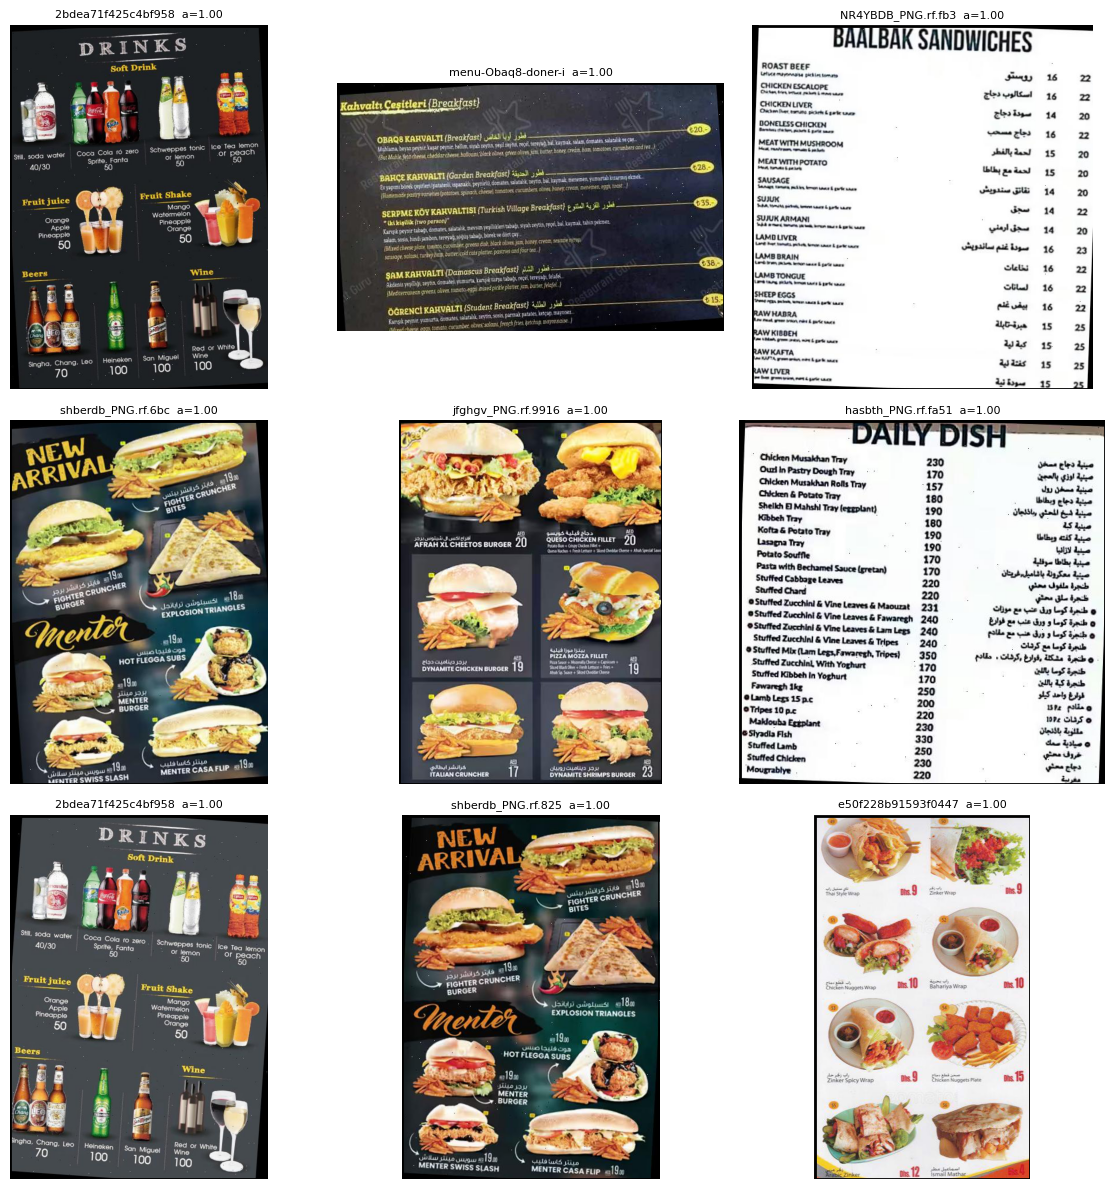

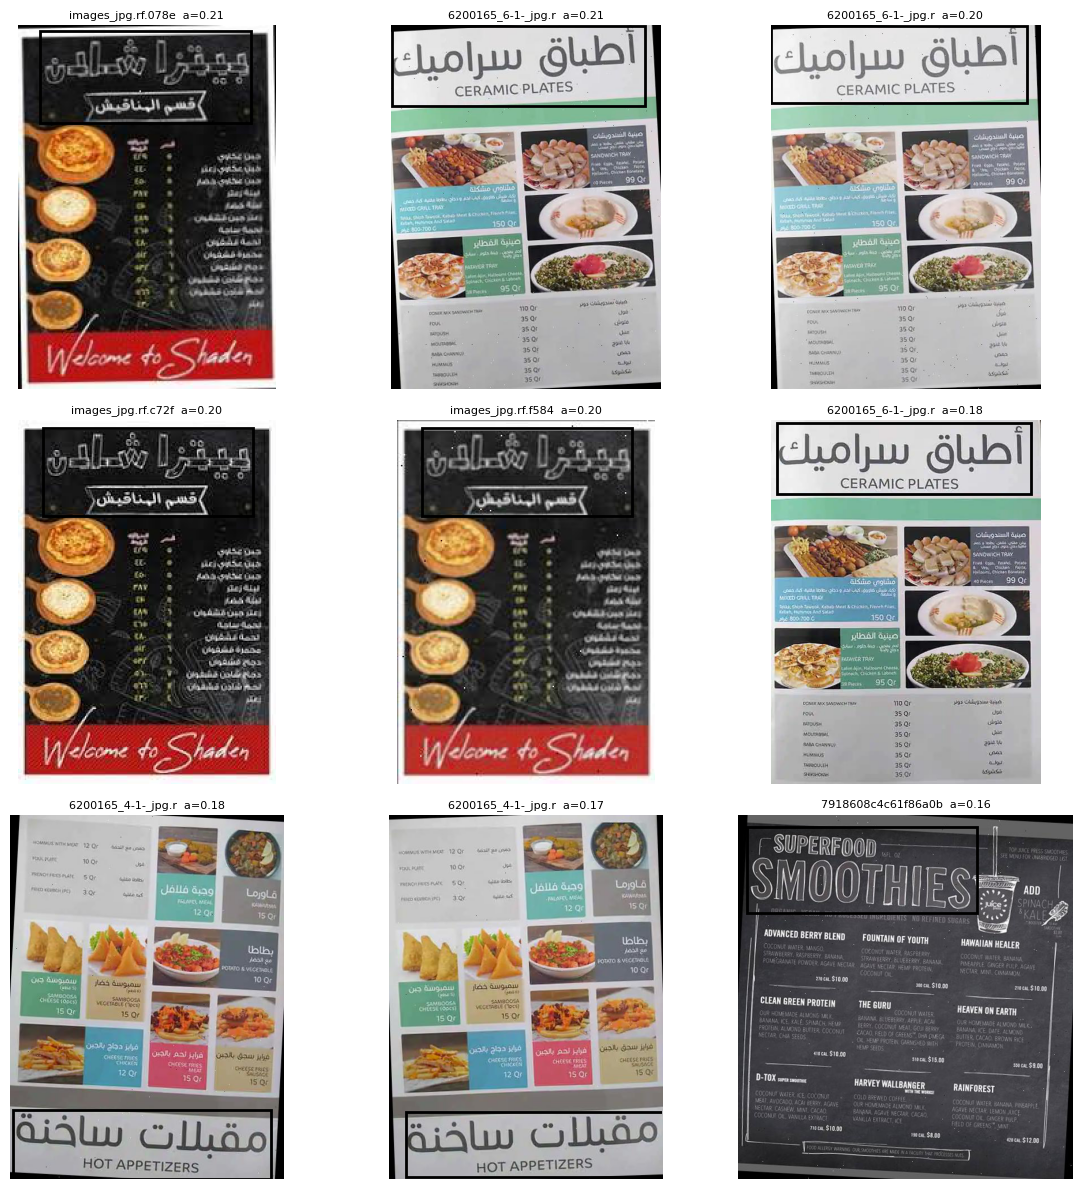

In [10]:
big_menu = (
    boxes_sup[boxes_sup["class_name"] == "menu-text"]
    .sort_values("bbox_area_frac", ascending=False)
    .head(9)
    .reset_index(drop=True)
)

big_res = (
    boxes_sup[boxes_sup["class_name"] == "res_name"]
    .sort_values("bbox_area_frac", ascending=False)
    .head(9)
    .reset_index(drop=True)
)

print("big_menu area_frac", big_menu["bbox_area_frac"].round(3).tolist())
print("big_res area_frac", big_res["bbox_area_frac"].round(3).tolist())

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")
for ax, (_, r) in zip(axes, big_menu.iterrows()):
    img = Image.open(project_root / r["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.add_patch(patches.Rectangle((r["x1"], r["y1"]), r["x2"] - r["x1"], r["y2"] - r["y1"], fill=False, linewidth=2))
    ax.set_title(f"{Path(r['image_path']).name[:18]}  a={r['bbox_area_frac']:.2f}", fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")
for ax, (_, r) in zip(axes, big_res.iterrows()):
    img = Image.open(project_root / r["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.add_patch(patches.Rectangle((r["x1"], r["y1"]), r["x2"] - r["x1"], r["y2"] - r["y1"], fill=False, linewidth=2))
    ax.set_title(f"{Path(r['image_path']).name[:18]}  a={r['bbox_area_frac']:.2f}", fontsize=8)
plt.tight_layout()
plt.show()


In [11]:
menu = boxes_sup[boxes_sup["class_name"] == "menu-text"].copy()

full = menu[(menu["bw"] >= 0.99) & (menu["bh"] >= 0.99)].copy()
near_full = menu[menu["bbox_area_frac"] >= 0.95].copy()

print("menu_boxes", len(menu))
print("full_boxes", len(full), "pct", round(len(full) / len(menu) * 100, 3))
print("near_full_boxes>=0.95", len(near_full), "pct", round(len(near_full) / len(menu) * 100, 3))

menu_imgs = menu[["split", "image_path"]].drop_duplicates()
full_imgs = full[["split", "image_path"]].drop_duplicates()
near_imgs = near_full[["split", "image_path"]].drop_duplicates()

by_split = menu_imgs.groupby("split").size().rename("menu_images").to_frame()
by_split["full_images"] = full_imgs.groupby("split").size()
by_split["near_full_images"] = near_imgs.groupby("split").size()
by_split = by_split.fillna(0).astype(int)
by_split["pct_full_images"] = (by_split["full_images"] / by_split["menu_images"] * 100).round(3)
by_split["pct_near_full_images"] = (by_split["near_full_images"] / by_split["menu_images"] * 100).round(3)

display(by_split)

display(
    full[["split", "image_path", "xc", "yc", "bw", "bh", "bbox_area_frac"]]
    .head(15)
)


menu_boxes 19406
full_boxes 51 pct 0.263
near_full_boxes>=0.95 114 pct 0.587


,menu_images,full_images,near_full_images,pct_full_images,pct_near_full_images
split,,,,,
test,275,1,7,0.364,2.545
train,3984,49,102,1.230,2.560
valid,461,1,5,0.217,1.085


,split,image_path,xc,yc,bw,bh,bbox_area_frac
2196,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.500000,0.503571,1.000000,0.992857,0.992857
2595,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.500000,0.500000,1.000000,1.000000,1.000000
2596,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.500000,0.500000,1.000000,1.000000,1.000000
5214,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.500833,0.500000,0.998333,1.000000,0.998333
7723,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.500000,0.500000,1.000000,1.000000,1.000000
7724,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.501160,0.500000,0.997680,1.000000,0.997680
8437,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.501675,0.500000,0.996650,1.000000,0.996650
8439,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.500000,0.500000,1.000000,1.000000,1.000000
8733,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.500000,0.500000,1.000000,1.000000,1.000000
8734,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,0.498366,0.500000,0.996748,1.000000,0.996748


In [12]:
img_cls = (
    boxes_sup.groupby(["split", "image_path", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

img_cls["n_boxes"] = img_cls[[c for c in class_names if c in img_cls.columns]].sum(axis=1)

img_cls = img_cls.merge(
    rf_supervised[["split", "image_path", "img_w", "img_h"]],
    on=["split", "image_path"],
    how="left",
)

display(
    img_cls.groupby("split").agg(
        n_images=("image_path", "count"),
        pct_has_menu_text=("menu-text", lambda s: round(100 * (s > 0).mean(), 3)),
        pct_has_res_name=("res_name", lambda s: round(100 * (s > 0).mean(), 3)),
        mean_menu_text=("menu-text", "mean"),
        mean_res_name=("res_name", "mean"),
        mean_boxes=("n_boxes", "mean"),
        p95_boxes=("n_boxes", lambda s: float(np.percentile(s, 95))),
        max_boxes=("n_boxes", "max"),
    )
)

display(
    img_cls.sort_values("n_boxes", ascending=False)[
        ["split", "image_path", "n_boxes", "menu-text", "res_name", "img_w", "img_h"]
    ].head(20)
)

res_imgs = img_cls[img_cls["res_name"] > 0].copy()
print("res_name_images_total", len(res_imgs))

sample_n = min(12, len(res_imgs))
display(
    res_imgs.sample(n=sample_n, random_state=42)[
        ["split", "image_path", "menu-text", "res_name", "img_w", "img_h"]
    ]
)


,n_images,pct_has_menu_text,pct_has_res_name,mean_menu_text,mean_res_name,mean_boxes,p95_boxes,max_boxes
split,,,,,,,,
test,275,100.0,6.909,4.200000,0.069091,4.269091,10.0,16
train,3984,100.0,18.223,4.109940,0.182229,4.292169,10.0,19
valid,461,100.0,13.666,4.071584,0.136659,4.208243,10.0,35


,split,image_path,n_boxes,menu-text,res_name,img_w,img_h
4365,valid,data/raw/roboflow_menu_text_box_v3/Menu Text B...,35,34,1,564,862
4355,valid,data/raw/roboflow_menu_text_box_v3/Menu Text B...,30,30,0,564,1649
4364,valid,data/raw/roboflow_menu_text_box_v3/Menu Text B...,25,25,0,1435,2048
4260,valid,data/raw/roboflow_menu_text_box_v3/Menu Text B...,20,20,0,960,960
2314,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,19,19,0,488,700
2313,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,19,19,0,488,700
4526,valid,data/raw/roboflow_menu_text_box_v3/Menu Text B...,19,19,0,429,700
1573,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,19,19,0,563,863
1572,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,19,19,0,563,863
1571,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,19,19,0,563,863


res_name_images_total 808


,split,image_path,menu-text,res_name,img_w,img_h
3752,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,2,1,598,800
1374,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,7,1,525,700
1215,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,2,1,300,488
1639,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,2,1,300,488
2620,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,6,1,561,787
4553,valid,data/raw/roboflow_menu_text_box_v3/Menu Text B...,3,1,2000,1414
1078,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,8,1,564,367
1271,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,5,1,2048,1658
2177,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,8,1,1200,1720
2778,train,data/raw/roboflow_menu_text_box_v3/Menu Text B...,1,1,564,783


res_boxes_total 808


split
test      19
train    726
valid     63
dtype: int64

,xc,yc,bw,bh,bbox_area_frac,bbox_w_px,bbox_h_px
0.01,0.106111,0.036448,0.081606,0.026704,0.003122,41.0574,18.07
0.05,0.177166,0.049503,0.117266,0.038739,0.006219,62.3430,23.74
0.25,0.284512,0.074178,0.224625,0.059104,0.014831,115.9125,37.00
0.50,0.497405,0.110560,0.317571,0.083499,0.027206,161.3600,57.07
0.75,0.534771,0.162596,0.468422,0.118951,0.049223,259.0000,95.00
0.95,0.834960,0.741064,0.713202,0.173333,0.084616,506.5500,170.30
0.99,0.893490,0.940096,0.856058,0.249880,0.162333,845.0469,262.37


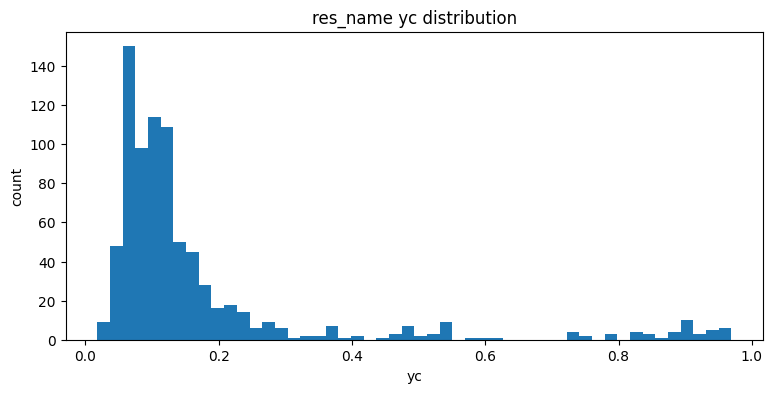

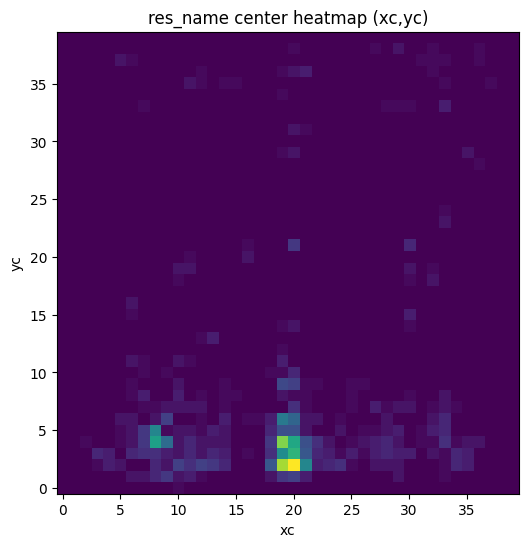

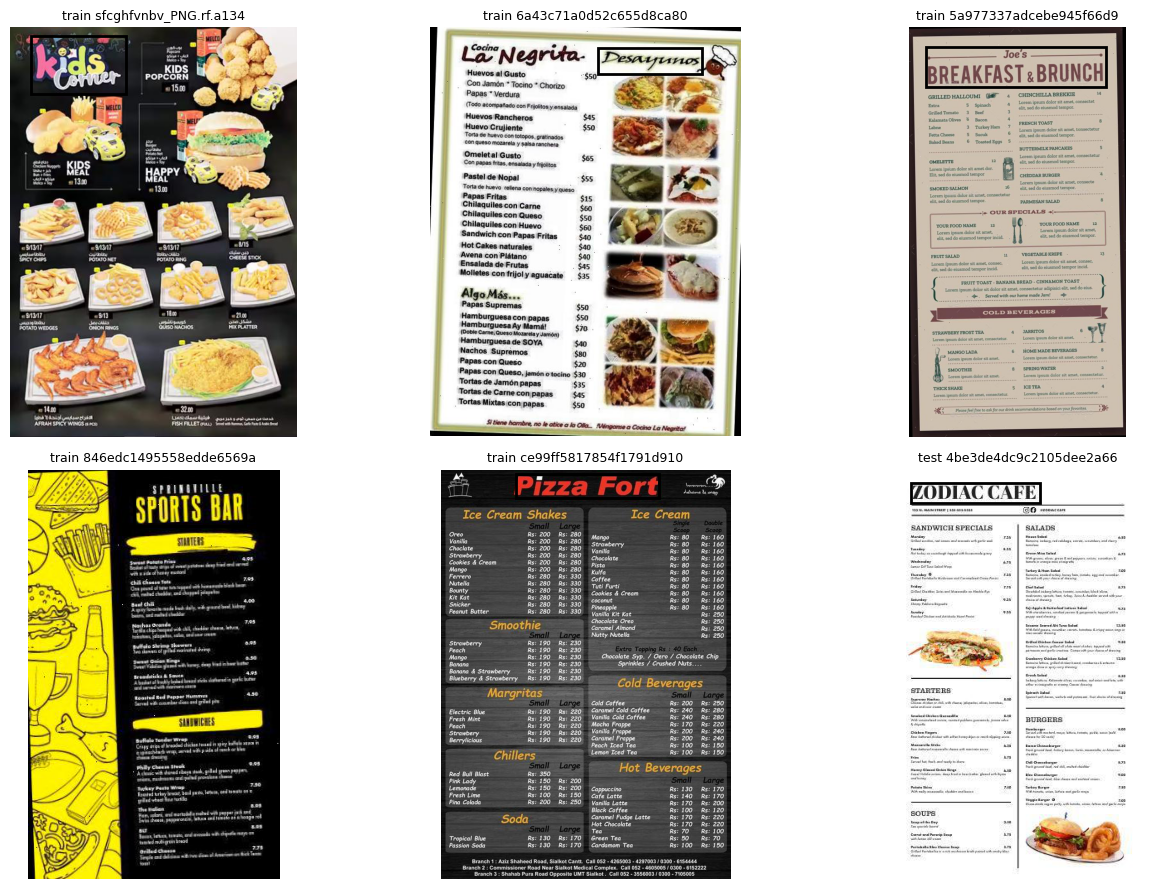

In [13]:
res_boxes = boxes_sup[boxes_sup["class_name"] == "res_name"].copy()
print("res_boxes_total", len(res_boxes))
display(res_boxes.groupby("split").size())

display(res_boxes[["xc", "yc", "bw", "bh", "bbox_area_frac", "bbox_w_px", "bbox_h_px"]].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(res_boxes["yc"], bins=50)
ax.set_title("res_name yc distribution")
ax.set_xlabel("yc")
ax.set_ylabel("count")
plt.show()

H, _, _ = np.histogram2d(res_boxes["xc"], res_boxes["yc"], bins=40, range=[[0, 1], [0, 1]])
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(H.T, origin="lower", aspect="equal")
ax.set_title("res_name center heatmap (xc,yc)")
ax.set_xlabel("xc")
ax.set_ylabel("yc")
plt.show()

res_imgs_sample = (
    res_boxes[["split", "image_path"]]
    .drop_duplicates()
    .sample(n=min(6, res_boxes[["split", "image_path"]].drop_duplicates().shape[0]), random_state=42)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")

for ax, (_, r) in zip(axes, res_imgs_sample.iterrows()):
    img = Image.open(project_root / r["image_path"]).convert("RGB")
    ax.imshow(img)

    bb = res_boxes[(res_boxes["split"] == r["split"]) & (res_boxes["image_path"] == r["image_path"])]
    for _, b in bb.iterrows():
        ax.add_patch(patches.Rectangle((b["x1"], b["y1"]), b["x2"] - b["x1"], b["y2"] - b["y1"], fill=False, linewidth=2))

    ax.set_title(f"{r['split']} {Path(r['image_path']).name[:22]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [14]:
splits = ["train", "valid", "test"]

fixed_files = []
converted_poly_lines = 0

for split in splits:
    lbl_dir = roboflow_root / split / "labels"
    for lp in sorted(lbl_dir.rglob("*.txt")):
        lines = lp.read_text(encoding="utf-8").splitlines()
        new_lines = []
        changed = False

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 0:
                continue

            if len(parts) == 5:
                new_lines.append(line.strip())
                continue

            if len(parts) > 5 and (len(parts) - 1) % 2 == 0:
                cls = int(float(parts[0]))
                coords = list(map(float, parts[1:]))
                xs = coords[0::2]
                ys = coords[1::2]
                xmin, xmax = min(xs), max(xs)
                ymin, ymax = min(ys), max(ys)
                xc = (xmin + xmax) / 2
                yc = (ymin + ymax) / 2
                bw = xmax - xmin
                bh = ymax - ymin
                new_lines.append(f"{cls} {xc} {yc} {bw} {bh}")
                changed = True
                converted_poly_lines += 1
                continue

            new_lines.append(line.strip())

        if changed:
            bak = lp.with_suffix(lp.suffix + ".bak")
            if not bak.exists():
                bak.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
            lp.write_text("\n".join(new_lines) + ("\n" if new_lines else ""), encoding="utf-8")
            fixed_files.append(str(lp.relative_to(project_root)))

print("fixed_label_files", len(fixed_files))
print("converted_poly_lines", converted_poly_lines)
fixed_files[:5]


fixed_label_files 1
converted_poly_lines 1


['data/raw/roboflow_menu_text_box_v3/Menu Text Box/test/labels/9f58ad73e6bf197be87ddf91b792faba_jpg.rf.3b66e4d9ae5b1e1f254bb4ed8b380379.txt']

In [18]:
import pandas as pd
from PIL import Image

kg_paths = sorted([p for p in kaggle_root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

rows = []
for p in kg_paths:
    rel = str(p.relative_to(project_root))
    ext = p.suffix.lower()
    b = p.stat().st_size

    w = None
    h = None
    ok = 1
    err = ""

    try:
        with Image.open(p) as im:
            im.verify()
        with Image.open(p) as im:
            w, h = im.size
    except Exception as e:
        ok = 0
        err = type(e).__name__

    rows.append([rel, w, h, b, ext, ok, err])

kaggle_df = pd.DataFrame(rows, columns=["image_path", "img_w", "img_h", "image_bytes", "ext", "ok", "err"])
kaggle_bad = kaggle_df[kaggle_df["ok"] == 0].copy()
kaggle_ok = kaggle_df[kaggle_df["ok"] == 1].copy()

print("kaggle_total", len(kaggle_df))
print("kaggle_ok", len(kaggle_ok))
print("kaggle_bad", len(kaggle_bad))
print(kaggle_bad["err"].value_counts().head(10))

interim_dir = data_root / "interim"
interim_dir.mkdir(parents=True, exist_ok=True)
kaggle_df.to_csv(interim_dir / "kaggle_manifest.csv", index=False)
kaggle_bad.to_csv(interim_dir / "kaggle_bad_images.csv", index=False)

kaggle_bad.head(20)


kaggle_total 7790
kaggle_ok 7789
kaggle_bad 1
err
UnidentifiedImageError    1
Name: count, dtype: int64


,image_path,img_w,img_h,image_bytes,ext,ok,err
6818,data/raw/kaggle_indian_menu_cards/7136.jpg,NaN,NaN,0,.jpg,0,UnidentifiedImageError


In [19]:
import numpy as np
from IPython.display import display

kaggle_ok = kaggle_df[kaggle_df["ok"] == 1].copy()
kaggle_ok["aspect_ratio"] = kaggle_ok["img_w"] / kaggle_ok["img_h"]
kaggle_ok["img_area"] = kaggle_ok["img_w"] * kaggle_ok["img_h"]
kaggle_ok["is_portrait"] = kaggle_ok["img_h"] >= kaggle_ok["img_w"]

print("kaggle_ok", len(kaggle_ok))
display(kaggle_ok["ext"].value_counts())

display(kaggle_ok["is_portrait"].value_counts())

display(
    kaggle_ok[["img_w", "img_h", "aspect_ratio", "img_area", "image_bytes"]]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)


kaggle_ok 7789


ext
.jpg     7691
.png       51
.jpeg      47
Name: count, dtype: int64

is_portrait
True     6687
False    1102
Name: count, dtype: int64

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
img_w,7789.0,548.545256,204.446887,223.00000,350.00,377.000000,459.000000,522.000000,600.0,650.000000,1.350000e+03,3.511000e+03
img_h,7789.0,674.459366,241.921919,88.00000,371.88,459.000000,600.000000,700.000000,700.0,700.000000,1.768000e+03,4.096000e+03
aspect_ratio,7789.0,0.839969,0.243927,0.46176,0.50,0.562219,0.684286,0.765714,1.0,1.359833,1.654450e+00,2.674897e+00
img_area,7789.0,405888.406086,627886.832011,19624.00000,185434.60,235760.400000,298200.000000,346500.000000,368900.0,455000.000000,2.430000e+06,1.258291e+07
image_bytes,7789.0,81270.269097,108502.350582,4521.00000,16583.92,20209.000000,47398.000000,70486.000000,95199.0,138094.600000,3.110206e+05,2.337008e+06
